In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix

## Load Data

In [3]:
def read_fasta(path):
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line: 
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
            
    return headers, sequences

def load_labels(path):
    label_dict = {}
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            parts = line.strip().split('\t')
            header = parts[0][1:]
            if parts[1] == "FALSE":
                label = 0.0
            else:
                label = 1.0
            label_dict[header] = label
    return label_dict

## Data Processing

In [4]:
# mapping ACGT to 0123
# mapping acgt to 0123
# mapping N and others to T

ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# reverse complement ACGTN -> TGCAN -> 32104
REV_COMP = torch.tensor([3, 2, 1, 0, 4]) 

In [5]:
class SeqDataset(Dataset):
    def __init__(self, headers, sequences, labels):
        self.headers = headers
        self.sequences = sequences
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.headers[idx], self.sequences[idx].encode('ascii', 'ignore'), self.labels[idx]

In [6]:
def collate_pad(batch):
    headers, seq_bytes, labels = zip(*batch)
    idx_list = [ENCODE[np.frombuffer(sb, dtype=np.uint8)] for sb in seq_bytes]
    max_length = max(x.size for x in idx_list)
    batch_size = len(idx_list)
    
    X = torch.zeros(batch_size, 5, max_length, dtype=torch.float32)   # channels: A, C, G, T, N
    mask = torch.zeros(batch_size, max_length, dtype=torch.bool)      # padding mask
    
    for i, idx_np in enumerate(idx_list):
        length = idx_np.size
        idx = torch.from_numpy(idx_np).long()
        X[i, idx, torch.arange(length)] = 1.0
        mask[i, :length] = (idx != 4)   # invalid positions: N or everything beyond the length
    
    Y = torch.tensor(labels, dtype=torch.float32)
    return headers, X, mask, Y

## CNN Network

In [7]:
# Reverse complement convolution layer
# input: one-hot (B, 5, L)
# output: RC-invariant feature map (B, C, L)

def rc_kernel(k: torch.Tensor):
    # Reverse complement the convolution kernel
    # k: (out_channels, in_channels, length)
    k_flip = k.flip(-1)
    return k_flip.index_select(1, REV_COMP.to(k.device))

class RCFirstConv1d(nn.Module):
    
    def __init__(self, out_channels, kernel_size, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        
        y1 = self.conv(x)             # (B, C, L)
        
        x_rc = x.flip(-1)[:, REV_COMP.to(x.device), :]
        y2 = self.conv(x_rc)          # (B, C, L)
        y2 = y2.flip(-1)
        
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        
        return y 

In [42]:
class MaskedMaxPool1d(nn.Module):
    def __init__(self, kernel_size, stride=2):
        super().__init__()
        self.kernel_size, self.stride = kernel_size, stride

    def forward(self, x, mask):  # x:(B, C, L), mask:(B, L)
        m = mask.unsqueeze(1)
        x_masked = x.masked_fill(~m, float('-inf'))
        y = F.max_pool1d(x_masked, self.kernel_size, self.stride)
        m_pooled = F.max_pool1d(m.float(), self.kernel_size, self.stride) > 0
        y = y.masked_fill(~m_pooled, 0.0)
        return y, m_pooled.squeeze(1)

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation)
        self.batch_norm = nn.BatchNorm1d(c_out)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.dropout(F.gelu(self.batch_norm(self.conv(x))))

class MaskedAttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.query = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1)

    def forward(self, x, mask=None):  # x: (B, C, L)
        x_t = x.transpose(1, 2)  # (B, L, C)
        attn_scores = self.score(torch.tanh(self.query(x_t))).squeeze(-1)  # (B, L)
        attn = torch.softmax(attn_scores, dim=-1)
        if mask is not None:
            mask_f = mask.float()
            attn = attn * mask_f
            norm = mask_f.sum(dim=-1, keepdim=True).clamp_min(1e-6)
            attn = attn / norm
        pooled = torch.bmm(attn.unsqueeze(1), x_t).squeeze(1)
        return pooled

In [43]:
class RCInputInvariantCNN(nn.Module):
    def __init__(
            self, 
            motif_width = 64, motif_kernel = (9, 15, ), 
            context_width = (128, 256, ), context_kernel = (7, 5, ), context_dilation = (1, 2, )
        ):
        super().__init__()

        self.motif_conv_blocks = nn.ModuleList(
            RCFirstConv1d(out_channels=motif_width, kernel_size=ker, dilation=1, dropout=0.2)
            for ker in motif_kernel
        )
        dim = motif_width * len(motif_kernel)

        self.context_blocks = nn.ModuleList()
        c_in = dim
        for width, ker, dil in zip(context_width, context_kernel, context_dilation):
            self.context_blocks.append(
                ConvBlock(c_in, c_out=width, kernel_size=ker, dilation=dil, dropout=0.2)
            )
            c_in = width

        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)
        head_in_features = c_in
        self.attention_pool = MaskedAttentionPooling(head_in_features)

        self.head = nn.Sequential(
            nn.Linear(head_in_features, width),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(width, 1),
        )

    @staticmethod
    def masked_avg_pool(z, mask):
        if mask is None:
            return z.mean(-1)
        m = mask.unsqueeze(1).float()
        return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

    def forward(self, x, mask):
        
        motif_outputs = [motif_conv(x) for motif_conv in self.motif_conv_blocks]
        z = torch.cat(motif_outputs, dim=1)

        for block in self.context_blocks:
            try:
                z_new = block(z)
                if z_new.shape == z.shape:
                    z = z_new + z
                else:
                    z = z_new
            except RuntimeError:
                z = block(z)
            z, mask = self.pool(z, mask)

        z_pooled = self.attention_pool(z, mask)
        out = self.head(z_pooled).squeeze(-1)
        
        return out

## Train & Eval

In [10]:
def resolve_device(requested=None):
    """Return the best available accelerator as a torch.device."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [46]:
with torch.no_grad():
    device = resolve_device()
    model = RCInputInvariantCNN().to(device)
    X = torch.randn(3, 5, 64, device=device)
    mask = torch.zeros(3, 64, dtype=torch.bool, device=device)
    mask[0, :120] = True
    mask[1, :100] = True
    mask[2, :80] = True
    out = model(X, mask)
    print('Device:', device)
    print('Output shape:', out.shape)

Device: mps
Output shape: torch.Size([3])


In [12]:
def save_torch(data, path, filename): 
    os.makedirs(path, exist_ok=True)
    if os.path.exists("%s/%s.pt"%(path, filename)):
        n = 1
        while n <= 100:
            if os.path.exists("%s/%s_legend_%s.pt"%(path, filename, n)):
                n += 1
            else:
                torch.save(data, "%s/%s_legend_%s.pt"%(path, filename, n))
                break
    else:
        torch.save(data, "%s/%s.pt"%(path, filename))

In [13]:
def prepare_data(fasta_path, label_path, subset_size=None, random_state=42):
    headers, sequences = read_fasta(fasta_path)
    label_dict = load_labels(label_path)
    labels = [label_dict[h] for h in headers]
    
    total_sequences = len(sequences)
    if subset_size is not None and subset_size < total_sequences:
        rng = np.random.default_rng(random_state)
        perm = rng.permutation(total_sequences)
        sel_idx = np.sort(perm[:subset_size])
        headers = [headers[i] for i in sel_idx]
        sequences = [sequences[i] for i in sel_idx]
        labels = [labels[i] for i in sel_idx]
        print(f"Using random subset of {len(headers)} sequences (from {total_sequences}) with random_state={random_state}.")
    else:
        print(f"Using all {total_sequences} sequences for training.")

    idx_tr, idx_te = train_test_split(
        np.arange(len(sequences)), test_size=0.2, train_size=0.6, stratify=labels, random_state=42
    )
    idx_val = np.setdiff1d(np.arange(len(sequences)), np.concatenate([idx_tr, idx_te]))
    ds_tr = SeqDataset([headers[i] for i in idx_tr], [sequences[i] for i in idx_tr], [labels[i] for i in idx_tr])
    ds_val = SeqDataset([headers[i] for i in idx_te], [sequences[i] for i in idx_te], [labels[i] for i in idx_te])
    ds_te = SeqDataset([headers[i] for i in idx_val], [sequences[i] for i in idx_val], [labels[i] for i in idx_val])
    
    return ds_tr, ds_val, ds_te

In [14]:
def train_one_epoch(model, loader, opt, loss_fn, device, ep, epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {ep}/{epochs}", leave=False)
    for _, X, mask, Y in pbar:
        X, mask, Y = X.to(device), mask.to(device), Y.to(device)
        opt.zero_grad()
        logits = model(X, mask)
        loss = loss_fn(logits, Y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * X.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss

def evaluate(model, loader, loss_fn, device, dataset):
    model.eval()
    val_running = 0.0
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for _, X, mask, Y in tqdm(loader, desc="Val", leave=False):
            X, mask = X.to(device, dtype=torch.float32), mask.to(device)
            Y, logits = Y.to(device, dtype=torch.float32), model(X, mask)
            loss = loss_fn(logits, Y)
            val_running += loss.item() * X.size(0)
            all_logits.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(Y.detach().cpu().numpy())
    all_logits = np.concatenate(all_logits) if all_logits else np.array([])
    all_labels = np.concatenate(all_labels) if all_labels else np.array([])
    val_loss = val_running / len(dataset) if len(dataset) else float("nan")
    
    try:
        auroc = roc_auc_score(all_labels, all_logits)
        auprc = average_precision_score(all_labels, all_logits)
    except ValueError:
        auroc, auprc = float("nan"), float("nan")
    return auroc, auprc, val_loss, all_logits, all_labels

In [15]:
resolve_device(device)

device(type='mps')

In [ ]:
def run_train(fasta_path, label_path, batch_size=8, epochs=5, lr=1e-3, device=None, patience=10, subset_size=None, random_state=42, trial=False, pos_weight=None):
    device = resolve_device(device)
    print(f"Using device: {device}")

    ds_tr, ds_val, ds_te = prepare_data(fasta_path, label_path, subset_size=subset_size, random_state=random_state)
    loader_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_pad)
    loader_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad)
    loader_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad)

    # The dataset is highly imbalanced; compute pos_weight if not provided
    if pos_weight is None:
        train_labels = torch.tensor(ds_tr.labels, dtype=torch.float32)
        pos_count = float(train_labels.sum().item())
        neg_count = float(train_labels.numel() - pos_count)
        if pos_count == 0:
            pos_weight_value = 1.0
        else:
            pos_weight_value = max(neg_count / pos_count, 1.0)
        print(f"Computed pos_weight={pos_weight_value:.4f} from dataset (pos={pos_count:.0f}, neg={neg_count:.0f})")
        pos_weight_tensor = torch.tensor(pos_weight_value, device=device)
    else:
        if isinstance(pos_weight, torch.Tensor):
            pos_weight_tensor = pos_weight.to(device)
            pos_weight_value = float(pos_weight_tensor.item())
        else:
            pos_weight_value = float(pos_weight)
            pos_weight_tensor = torch.tensor(pos_weight_value, device=device)
        print(f"Using provided pos_weight={pos_weight_value:.4f}")

    model = RCInputInvariantCNN().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    print("Starting training...")

    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}
    best_state, best_epoch = None, None
    best_metrics = {"auroc": -float("inf"), "auprc": float("nan"), "val_loss": float("inf")}
    best_scores, best_labels = None, None
    last_scores, last_labels = None, None
    last_val_loss = None
    last_auroc, last_auprc = None, None
    bad = 0
    patience = patience if patience is not None else epochs + 1

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch(model, loader_tr, opt, loss_fn, device, ep, epochs)

        auroc, auprc, val_loss, Ps, Ys = evaluate(model, loader_val, loss_fn, device, ds_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auroc"].append(auroc)
        history["val_auprc"].append(auprc)

        print(f"Epoch {ep}: train loss {train_loss:.4f} | Val loss {val_loss:.4f} | Val AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

        last_scores, last_labels = Ps, Ys
        last_val_loss, last_auroc, last_auprc = val_loss, auroc, auprc

        improved = (auroc - best_metrics["auroc"] > val_loss - best_metrics["val_loss"])
        print(improved, auroc > best_metrics["auroc"], val_loss < best_metrics["val_loss"])
        if improved:
            best_metrics = {"auroc": auroc, "auprc": auprc, "val_loss": val_loss}
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_scores, best_labels, best_epoch = Ps, Ys, ep
            bad = 0
            torch.save(best_state, "vgp_model_data_tpase/rc_cnn_latest.pt")
        else:
            bad += 1
            print(f"No improvement for {bad} epochs.")
            if bad >= patience:
                print("Early stopping.")
                break
        if auroc == 1:
            print("Early stopping.")
            break

    if best_state is not None:
        if not trial:
            save_torch(best_state, "vgp_model_data_tpase", "rc_cnn_best")
            model.load_state_dict(best_state)
            model.to(device)
    else:
        best_scores, best_labels = last_scores, last_labels
        best_epoch = best_epoch if best_epoch is not None else len(history["train_loss"])
        best_metrics = {
            "auroc": last_auroc,
            "auprc": last_auprc,
            "val_loss": last_val_loss,
        }

    auroc, auprc, te_loss, te_scores, te_labels = evaluate(model, loader_te, loss_fn, device, ds_te)
    print(f"Test set performance: Loss {te_loss:.4f} | AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

    results = {
        "model": model,
        "history": history,
        "metrics": {
            "best_epoch": best_epoch,
            "best_auroc": best_metrics["auroc"],
            "best_auprc": best_metrics["auprc"],
            "best_val_loss": best_metrics["val_loss"],
            "test_auroc": auroc,
            "test_auprc": auprc,
            "test_loss": te_loss,
        },
        "roc": {
            "labels": te_labels,
            "scores": te_scores,
            "best_labels": best_labels,
            "best_scores": best_scores,
        },
        "device": str(device),
        "pos_weight": pos_weight_value,
    }
    return results

In [63]:
fasta_path = '../data/vgp/all_vgp_tes.fa'
label_path = '../data/vgp/features.txt'
subset_size = 10000  # set to None to use the full dataset
subset_seed = 42

headers, sequences = read_fasta(fasta_path)
label_dict = load_labels(label_path)
labels = [label_dict[h] for h in headers]

In [64]:
# Long-running cell: executes full training
results = run_train(fasta_path, label_path, epochs=100, patience=10, subset_size=subset_size, random_state=subset_seed)

Using device: mps
Using random subset of 10000 sequences (from 135751) with random_state=42.
Computed pos_weight=2.3315 from dataset (pos=1801, neg=4199)
Starting training...


Epoch 1/100:   0%|          | 0/750 [00:00<?, ?it/s]

Val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1: train loss 0.6101 | Val loss 0.6033 | Val AUROC 0.4866 | AUPRC 0.2767
True True True


Epoch 2/100:   0%|          | 0/750 [00:00<?, ?it/s]

...

Epoch 17/100:   0%|          | 0/750 [00:00<?, ?it/s]

Val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 17: train loss 0.4085 | Val loss 0.6576 | Val AUROC 0.7087 | AUPRC 0.5419
False True False
No improvement for 10 epochs.
Early stopping.


Val:   0%|          | 0/250 [00:00<?, ?it/s]

Test set performance: Loss 0.5640 | AUROC 0.7085 | AUPRC 0.5105


In [65]:
results

{'model': RCInputInvariantCNN(
   (motif_conv_blocks): ModuleList(
     (0): RCFirstConv1d(
       (conv): Conv1d(5, 64, kernel_size=(9,), stride=(1,), padding=(4,))
       (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.2, inplace=False)
     )
     (1): RCFirstConv1d(
       (conv): Conv1d(5, 64, kernel_size=(15,), stride=(1,), padding=(7,))
       (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.2, inplace=False)
     )
   )
   (context_blocks): ModuleList(
     (0): ConvBlock(
       (conv): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
       (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.2, inplace=False)
     )
     (1): ConvBlock(
       (conv): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
       (batch_no

## Plot the results

In [52]:
def plot_training_curves(history):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
    if len(epochs) == 0:
        raise ValueError("History is empty; run training first.")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train loss", marker="o")
    axes[0].plot(epochs, history["val_loss"], label="Val loss", marker="o")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].set_title("Loss curves")
    axes[0].legend()
    axes[1].plot(epochs, history["val_auroc"], label="Val AUROC", marker="o")
    axes[1].plot(epochs, history["val_auprc"], label="Val AUPRC", marker="o")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation metrics")
    axes[1].legend()
    fig.tight_layout()
    return axes

def plot_roc(labels, scores):
    if labels is None or scores is None:
        raise ValueError("ROC data is missing; ensure training completed successfully.")
    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Validation ROC curve")
    plt.legend(loc="lower right")
    plt.grid(True)

array([<Axes: title={'center': 'Loss curves'}, xlabel='Epoch', ylabel='Binary cross-entropy'>,
       <Axes: title={'center': 'Validation metrics'}, xlabel='Epoch', ylabel='Score'>],
      dtype=object)

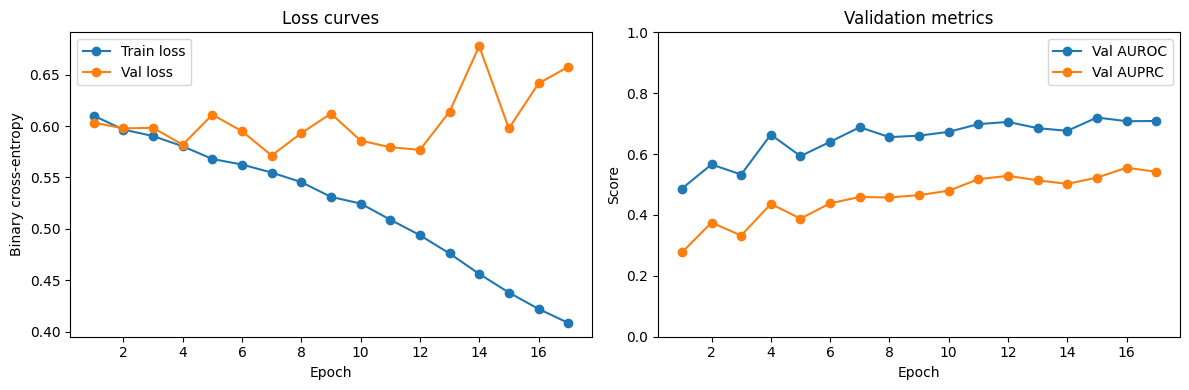

In [66]:
history = results["history"]
plot_training_curves(history)

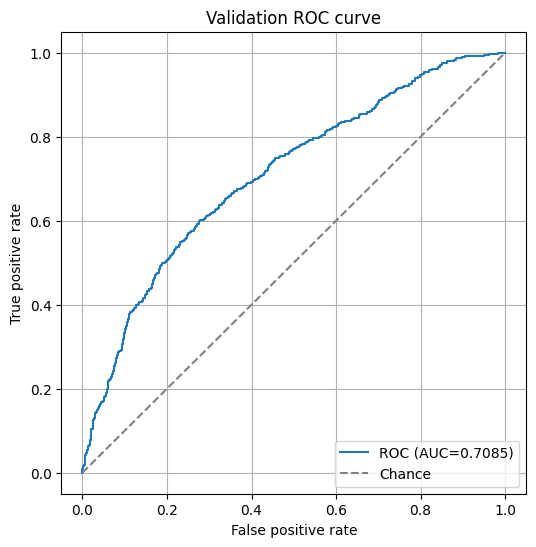

In [67]:
roc_data = results["roc"]
plot_roc(roc_data["labels"], roc_data["scores"])

In [68]:
headers, seqs = read_fasta(fasta_path)

ds_tr, ds_val, ds_te = prepare_data(fasta_path, label_path, subset_size=10000, random_state=7)
loader = DataLoader(ds_tr, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_pad)

all_headers, all_probs, all_logits = [], [], []

model.eval()
with torch.no_grad():
    for hdr_batch, X, mask, Y in tqdm(loader, desc="Val", leave=False):
        X = X.to(device, dtype=torch.float32)
        mask = mask.to(device)
        logits = model(X, mask)        # (B,) for binary or (B, n_classes) for multi
        probs = torch.sigmoid(logits)  # or softmax for multi
        all_headers.extend(hdr_batch)
        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_logits = np.concatenate(all_logits)

# Example: show top 10 “most positive” sequences
for i in range(20):
    print(all_headers[i], all_probs[i], labels[i])
    
print("logits mean/std/min/max:",
      all_logits.mean(), all_logits.std(),
      all_logits.min(), all_logits.max())

Using random subset of 10000 sequences (from 135751) with random_state=7.


Val:   0%|          | 0/750 [00:00<?, ?it/s]

Unknown_41-rRhiFlo#Unknown 0.48865616 1.0
hAT_467-aMixFle#DNA/hAT 0.48865604 1.0
Sola-2_1-fNanAch#DNA/Sola-2 0.4886561 0.0
Unknown_146-sHemOce#Unknown 0.48865604 0.0
DIRS_64-fLeuLeu#LTR/DIRS 0.48865628 0.0
ERV2_12-mJacJac#LTR/ERV2 0.48865616 0.0
Unknown_141-mCasCan#Unknown 0.48865595 0.0
L1_7-rDibSmi#LINE/L1 0.48865604 0.0
hAT_104-aBufBuf#Unknown 0.4886566 0.0
Unknown_23-bLycPyr#Unknown 0.48865658 0.0
Unknown_230-aXenPet#Unknown 0.4886566 0.0
hAT_625-aEngPus#DNA/hAT 0.4886566 0.0
Unknown_149-aMixFle#Unknown 0.48865652 1.0
Gypsy_17-fThaAma#LTR/Gypsy 0.48865673 1.0
Unknown_3-bPelCri#Unknown 0.4886566 1.0
hAT_206-fDirArg#DNA/hAT 0.4886566 1.0
Unknown_632-fNanAch#DNA 0.4886564 1.0
Unknown_142-aXenPet#Unknown 0.48865646 1.0
Unknown_77-fNotCoa#Unknown 0.4886564 1.0
Helitron_1-rBraPum#RC/Helitron 0.4886564 0.0
logits mean/std/min/max: -0.045382176 1.178609e-06 -0.045393676 -0.045379575
